<div class, class='alert alert-info'>

# This is the first assignment




half-mass radius (from function) = 0.808 pc


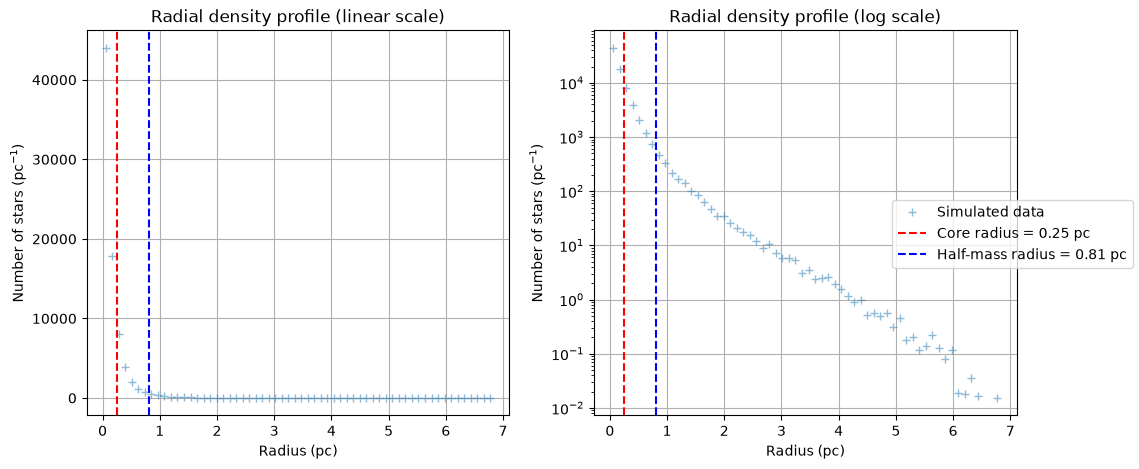

In [32]:
from amuse.units import units, constants, nbody_system
from amuse.lab import Particles, Particle
from amuse.io import read_set_from_file
import numpy as np
import matplotlib.pyplot as plt

particles = read_set_from_file('star_cluster_001.amuse', format='amuse')

particles.move_to_center()
x = particles.position.x.value_in(units.parsec)
y = particles.position.y.value_in(units.parsec)
z = particles.position.z.value_in(units.parsec)
r = np.sqrt(x**2 + y**2 + z**2)

counts, edges = np.histogram(r, bins=60, range=(0, r.max()))

r_center = (edges[:-1] + edges[1:]) / 2
shell_volume = 4 * np.pi * r_center**2 * np.diff(edges)
n_r = counts / shell_volume                     # stars / pc^3

def get_half_mass_radius(particles=particles, r=r):
    """Calculate the half-mass radius of a star cluster.
    Loop through the stars in order of increasing distance from the center, adding their mass until we reach half the total mass.
    Return the distance of the last star added.
    """
    
    #order the particles by distance from the center
    order = np.argsort(r)
    sorted_r = r[order]
    sorted_particles = particles[order]
    
    #initialize the mass to zero
    total_mass = particles.mass.sum()
    mass = 0.0 | units.kg
    # loop through the sorted stars and add their mass until we reach half the total mass
    for i in range(len(sorted_particles)):
        mass += sorted_particles[i].mass
        if mass >= total_mass / 2:
            return sorted_r[i]
    return None

# unit converter built from the total mass and the virial radius.
converter = nbody_system.nbody_to_si(particles.mass.sum(), particles.virial_radius())
# Core radius + core density (Casertano & Hut 1985, via the Hop code).
pos, rcore, rhocore = particles.densitycentre_coreradius_coredens(unit_converter=converter)
core_radius = converter.to_si(rcore).value_in(units.parsec)

half_mass_radius = get_half_mass_radius(particles=particles, r=r)
print(f'half-mass radius (from function) = {half_mass_radius:.3f} pc')


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(r_center, n_r, '+', alpha=0.5, label='Simulated data')
ax[0].set_xlabel('Radius (pc)')
ax[0].set_ylabel('Number of stars (pc$^{-1}$)')

ax[0].axvline(core_radius, color='red', linestyle='--', label=f'Core radius = {core_radius:.2f} pc')
ax[0].axvline(half_mass_radius, color='blue', linestyle='--', label=f'Half-mass radius = {half_mass_radius:.2f} pc')
ax[0].grid()
ax[0].set_title('Radial density profile (linear scale)')

ax[1].plot(r_center, n_r, '+', alpha=0.5)
ax[1].set_xlabel('Radius (pc)')
ax[1].set_ylabel('Number of stars (pc$^{-1}$)')
ax[1].set_yscale('log')

ax[1].axvline(core_radius, color='red', linestyle='--')
ax[1].axvline(half_mass_radius, color='blue', linestyle='--')
ax[1].grid()
ax[1].set_title('Radial density profile (log scale)')

fig.legend(loc='right')
plt.show()


<div class = 'alert alert-info'>

### Plot in Log space in the y axis

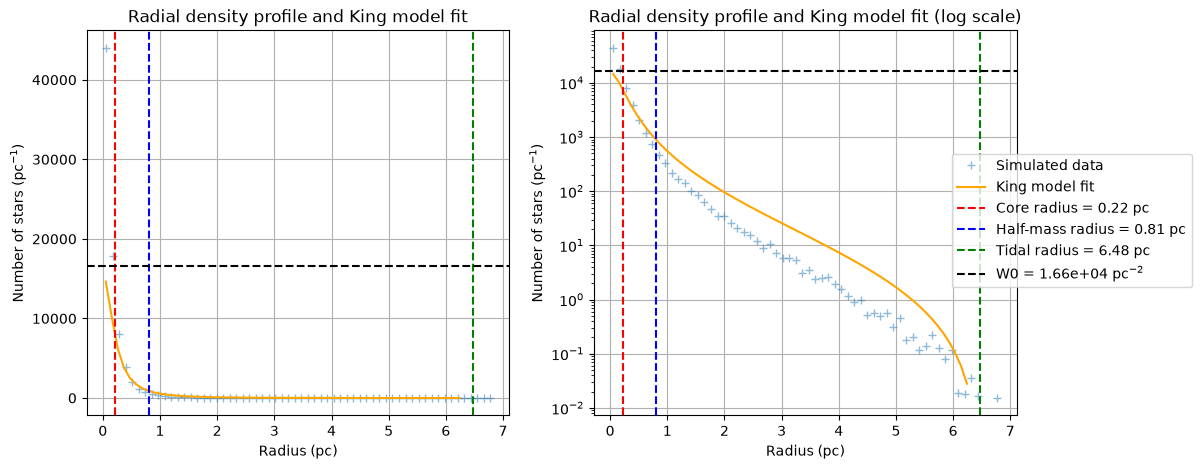

In [33]:
import scipy.optimize as opt

R = np.sqrt(x**2 + y**2)                         # project onto one plane
c2, e2 = np.histogram(R, bins=60, range=(0, R.max()))
R_center = (e2[:-1] + e2[1:]) / 2
annulus_area = np.pi * (e2[1:]**2 - e2[:-1]**2)
Sigma = c2 / annulus_area                        # stars / pc^2

def king_surface(R, W0, rc, rt):
    return W0 * (1/np.sqrt(1 + (R/rc)**2) - 1/np.sqrt(1 + (rt/rc)**2))**2

popt, _ = opt.curve_fit(king_surface, R_center, Sigma,
                        p0=[Sigma.max(), core_radius, R.max()], maxfev=20000)
W0, rc, rt = popt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(r_center, n_r, '+', alpha=0.5, label='Simulated data')
ax[0].plot(R_center, king_surface(R_center, W0, rc, rt), '-', color='orange', label='King model fit')
ax[0].set_xlabel('Radius (pc)')
ax[0].set_ylabel('Number of stars (pc$^{-1}$)')

ax[0].axvline(rc, color='red', linestyle='--', label=f'Core radius = {rc:.2f} pc')
ax[0].axvline(half_mass_radius, color='blue', linestyle='--', label=f'Half-mass radius = {half_mass_radius:.2f} pc')
ax[0].axvline(rt, color='green', linestyle='--', label=f'Tidal radius = {rt:.2f} pc')
ax[0].axhline(W0, color='black', linestyle='--', label=f'W0 = {W0:.2e} pc$^{{-2}}$')
ax[0].grid()
ax[0].set_title('Radial density profile and King model fit')

ax[1].plot(r_center, n_r, '+', alpha=0.5)
ax[1].plot(R_center, king_surface(R_center, W0, rc, rt), '-', color='orange')
ax[1].set_xlabel('Radius (pc)')
ax[1].set_ylabel('Number of stars (pc$^{-1}$)')
ax[1].set_yscale('log')

ax[1].axvline(rc, color='red', linestyle='--')
ax[1].axvline(half_mass_radius, color='blue', linestyle='--')
ax[1].axvline(rt, color='green', linestyle='--')
ax[1].axhline(W0, color='black', linestyle='--')
ax[1].grid()
ax[1].set_title('Radial density profile and King model fit (log scale)')

fig.legend(loc='center left', bbox_to_anchor=(0.84, 0.5))
plt.show()




 
 # Cluster analysis
 Some of the stars are concentrated in the smaller radii but there are several at much larger radii so using log bins seems good. For the dynamical state I use Q = T / U with a virialised cluster having Q = 0.5. I got the formulas for relaxation time from chapter 4 of the book and I used γ = 0.11 because it said its good for more realistic systems and that sounded good to me! ( Also changing it to 0.4, the other value it gives, doesn't change the result too much). The book also says that most systems are dissolved at about 10 relaxation times so I used that.



In [34]:
from functools import lru_cache
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import minimize_scalar
from amuse.ic.kingmodel import MakeKingModel

cluster = particles.copy()

def radial_number_density_profile(particles, n_bins=25):
    # Construct a 3d radial number density profile.
    p = particles.copy()
    p.move_to_center()

    radii = p.position.lengths().value_in(units.parsec)
    r_inner = np.percentile(radii, 1)

    edges = np.concatenate(
        ([0.0], np.geomspace(r_inner, radii.max(), n_bins))
    )
    counts, _ = np.histogram(radii, bins=edges)

    shell_volumes = (4.0 / 3.0) * np.pi * (
        edges[1:]**3 - edges[:-1]**3
    )
    density = counts / shell_volumes
    density_error = np.sqrt(counts) / shell_volumes
    r_mid = 0.5 * (edges[1:] + edges[:-1])

    return radii, edges, counts, r_mid, density, density_error

r_pc, edges, counts, r_mid, number_density, density_error = (
    radial_number_density_profile(cluster)
)

r_half = half_mass_radius | units.parsec

# Dynamical state
kinetic_energy = cluster.kinetic_energy()
potential_energy = cluster.potential_energy()
total_energy = kinetic_energy + potential_energy
q = kinetic_energy / abs(potential_energy)

# Relaxation and dissolution times
N = len(cluster)
M = cluster.mass.sum()
gamma = 0.11

t_dyn = (r_half**3 / (constants.G * M)).sqrt()
t_rh = 0.138 * N / np.log(gamma * N) * t_dyn
t_dis = 10.0 * t_rh

print(f"r_h = {r_half.in_(units.parsec)}")
print(f"T/|U| = {q}")
print(f"Total energy = {total_energy.in_(units.MSun * units.kms**2)}")
print(f"t_dyn = {t_dyn.in_(units.Myr)}")
print(f"t_rh = {t_rh.in_(units.Myr)}")
print(f"t_dis = {t_dis.in_(units.Myr)}")


r_h = 0.807583751542 parsec
T/|U| = 0.4995216534686666
Total energy = -39527.4715661 MSun * kms**2
t_dyn = 0.138989975991 Myr
t_rh = 27.3888867662 Myr
t_dis = 273.888867662 Myr


In [35]:
# ---- Survival time on a Solar-circle orbit in the Galactic tidal field ----
R_G = 8.0 | units.kpc                 # Galactocentric radius (Solar circle)
V_c = 220.0 | units.kms               # circular velocity of the Galaxy
Omega = V_c / R_G                     # orbital angular velocity

M = cluster.mass.sum()
N = len(cluster)

# Tidal (Jacobi) radius set by the Galactic tidal field
r_J = (constants.G * M / (2 * Omega**2))**(1.0 / 3.0)

# Dissolution time, Baumgardt & Makino (2003).
# Our King fit gives W0 = 7, for which (beta, x) = (1.03, 0.82); gamma = 0.02.
beta, x, gamma_bm = 1.03, 0.82, 0.02
t_diss = (beta * (N / np.log(gamma_bm * N))**x
          * R_G.value_in(units.kpc)
          * (220.0 / V_c.value_in(units.kms))) | units.Myr   # circular orbit: eps = 0

print(f"Jacobi radius r_J = {r_J.value_in(units.parsec):.2f} pc")
print(f"dissolution time t_diss = {t_diss.value_in(units.Gyr):.3f} Gyr")
print(f"(10 * t_rh from the cell above = {(10 * t_rh).value_in(units.Myr):.0f} Myr)")


Jacobi radius r_J = 25.83 pc
dissolution time t_diss = 4.001 Gyr
(10 * t_rh from the cell above = 274 Myr)


# King Model fit

We use the King model that AMUSE uses for generation initial conditions (the empirical king model does not provide W0, i think). For each w0 amuse gives us x = r / r_c  and d(x) =  ρ(r) / ρ_0  for the density profile ( i need to learn how to write latex in these comments).
$$ x = \frac{r}{r_c}$$
$$ d(x) = \frac{\rho(r)}{\rho_0}$$
We then change the r_c (the physical core radius) and check the expected number of stars in each radial shell with a Poisson likelihood with the observed counts. We start with a broad range and go smaller. I thought the likelihood would be good because discrete data and the outer shells contain much fewer stars than the inner ones.

Once we know W0 and r_c  , the king model gives us the tidal radius.

In [36]:
@lru_cache(maxsize=None) # this is to cache results so they can be resued, the arrays are small so it shouldnt be too much of an issue. We can remove it.
def king_profile(w0):
    king = MakeKingModel(number_of_particles=1, W0=float(w0))
    nprof, _ = king.poisson()

    x = np.asarray(king.rr[:nprof + 1], dtype=float)
    rho = np.asarray(king.d[:nprof + 1], dtype=float)
    rho = np.clip(rho, 0.0, None)

    integ = cumulative_trapezoid(rho * x**2, x, initial=0.0)
    return x, rho, integ

def fit_rc_for_w0(w0, edges_pc, counts, n_stars, r_max):
    # Find the maximum likelihood rc for a specific King W0
    x, _, integ = king_profile(float(w0))
    x_tidal = x[-1]
    total_integral = integ[-1]

    def nll(rc_pc):
        rt_pc = x_tidal * rc_pc
        if rt_pc <= r_max:
            return np.inf

        x_edges = np.clip(edges_pc / rc_pc, 0.0, x_tidal)
        integral_edges = np.interp(x_edges, x, integ)
        mu = n_stars * np.diff(integral_edges) / total_integral

        positive = counts > 0
        if np.any(mu[positive] <= 0):
            return np.inf

        # log(N_i!) is constant and i think can be skipped
        value = np.sum(mu)
        value -= np.sum(counts[positive] * np.log(mu[positive]))

        # Include the observed empty region from r_max to r_t
        fraction_inside = integral_edges[-1] / total_integral
        value += n_stars * (1.0 - fraction_inside)
        return value

    rc_lower = 1.001 * r_max / x_tidal
    rc_upper = 2.0 * r_max
    if rc_lower >= rc_upper:
        return None

    result = minimize_scalar(
        nll,
        bounds=(rc_lower, rc_upper),
        method="bounded",
    )
    if not result.success:
        return None

    return {
        "W0": float(w0),
        "rc": result.x,
        "rt": x_tidal * result.x,
        "rt_over_rc": x_tidal,
        "nll": result.fun,
    }

def fit_king_model(edges_pc, counts, n_stars, r_max, w0_min=1.0, w0_max=12.0):
    # Big and then more fine search in W0
    coarse_grid = np.arange(w0_min, w0_max + 0.001, 0.1)
    coarse = [
        fit_rc_for_w0(w0, edges_pc, counts, n_stars, r_max)
        for w0 in coarse_grid
    ]
    coarse = [result for result in coarse if result is not None]
    best_coarse = min(coarse, key=lambda result: result["nll"])

    fine_min = max(w0_min, best_coarse["W0"] - 0.3)
    fine_max = min(w0_max, best_coarse["W0"] + 0.3)
    fine_grid = np.arange(fine_min, fine_max + 0.001, 0.01)

    fine = [
        fit_rc_for_w0(w0, edges_pc, counts, n_stars, r_max)
        for w0 in fine_grid
    ]
    fine = [result for result in fine if result is not None]
    return min(fine, key=lambda result: result["nll"]), fine

best_fit, fit_results = fit_king_model(
    edges,
    counts,
    len(cluster),
    r_pc.max(),
)

W0_best = best_fit["W0"]
rc_best = best_fit["rc"]
rt_best = best_fit["rt"]
concentration = np.log10(rt_best / rc_best)

x_best, rho_best, integ_best = king_profile(W0_best)
n0_best = len(cluster) / (
    4.0 * np.pi * rc_best**3 * integ_best[-1]
)
r_model = x_best * rc_best
n_model = n0_best * rho_best

print("Best-fit King model")
print(f"W0 = {W0_best:.2f}")
print(f"rc = {rc_best:.4f} pc")
print(f"rt = {rt_best:.4f} pc")
print(f"c = log10(rt/rc) = {concentration:.3f}")


Best-fit King model
W0 = 7.00
rc = 0.2177 pc
rt = 7.3491 pc
c = log10(rt/rc) = 1.528


# Plotting

This is plotting for the two deliverables. I had some help from AI on this because I plotting is a headache. So I need to double check this.

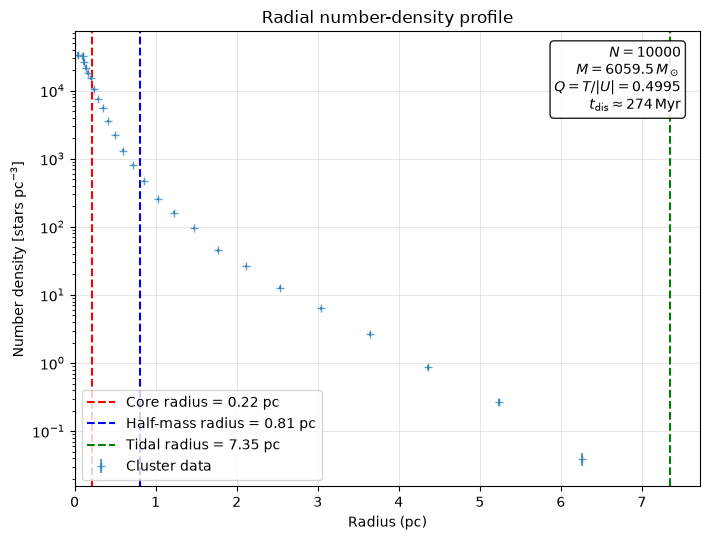

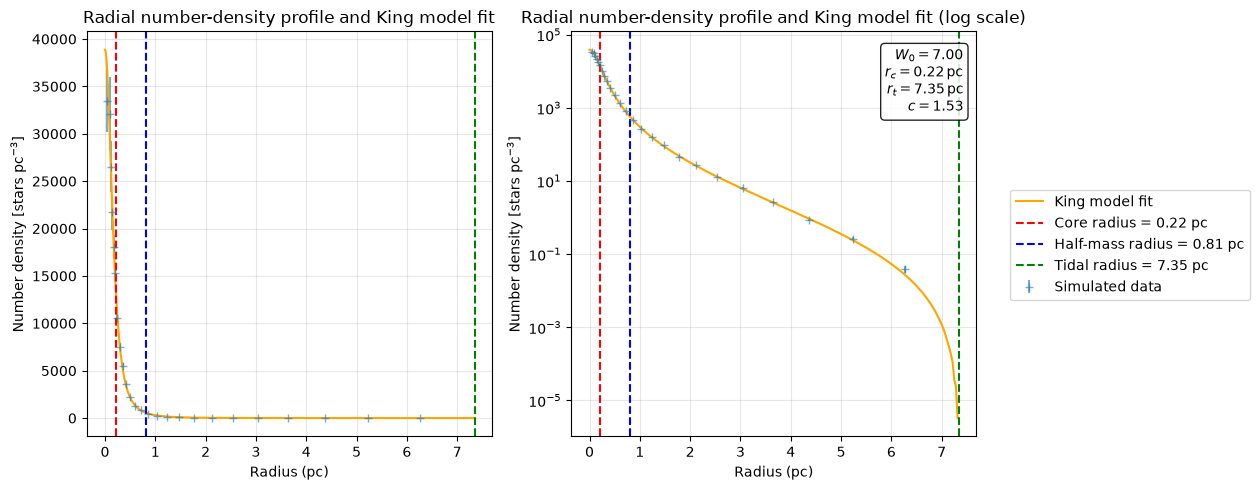

In [37]:
mask_data = counts > 0
mask_model = n_model > 0

# I had some trouble with units and data types
rh_best = r_half.value_in(units.parsec)
q_value = float(q)
M_value = cluster.mass.sum().value_in(units.MSun)
N_value = len(cluster)


# Figure 1 - cluster structure and dynamical state

plt.figure(figsize=(7.2, 5.5))

plt.errorbar(r_mid[mask_data], number_density[mask_data],
             yerr=density_error[mask_data],
             fmt='+', alpha=0.7, label='Cluster data')

plt.axvline(rc_best, color='red', linestyle='--',
            label=f'Core radius = {rc_best:.2f} pc')
plt.axvline(rh_best, color='blue', linestyle='--',
            label=f'Half-mass radius = {rh_best:.2f} pc')
plt.axvline(rt_best, color='green', linestyle='--',
            label=f'Tidal radius = {rt_best:.2f} pc')

info = (
    f'$N={N_value}$\n'
    f'$M={M_value:.1f}\\,M_\\odot$\n'
    f'$Q=T/|U|={q_value:.4f}$\n'
    f'$t_{{\\rm dis}}\\approx {t_dis.value_in(units.Myr):.0f}\\,\\rm Myr$'
)

plt.text(0.97, 0.97, info,
         transform=plt.gca().transAxes,
         ha='right', va='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.88))

plt.xlabel('Radius (pc)')
plt.ylabel(r'Number density [stars pc$^{-3}$]')
plt.yscale('log')
plt.xlim(0, 1.05 * rt_best)
plt.title('Radial number-density profile')
plt.grid(alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


# Figure 2 - King model fit

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Left panel - linear scale

ax[0].errorbar(r_mid[mask_data], number_density[mask_data],
               yerr=density_error[mask_data],
               fmt='+', alpha=0.6, label='Simulated data')

ax[0].plot(r_model[mask_model], n_model[mask_model],
           '-', color='orange', label='King model fit')

ax[0].axvline(rc_best, color='red', linestyle='--',
              label=f'Core radius = {rc_best:.2f} pc')
ax[0].axvline(rh_best, color='blue', linestyle='--',
              label=f'Half-mass radius = {rh_best:.2f} pc')
ax[0].axvline(rt_best, color='green', linestyle='--',
              label=f'Tidal radius = {rt_best:.2f} pc')

ax[0].set_xlabel('Radius (pc)')
ax[0].set_ylabel(r'Number density [stars pc$^{-3}$]')
ax[0].set_title('Radial number-density profile and King model fit')
ax[0].grid(alpha=0.3)


# Right panel - log scale

ax[1].errorbar(r_mid[mask_data], number_density[mask_data],
               yerr=density_error[mask_data],
               fmt='+', alpha=0.6)

ax[1].plot(r_model[mask_model], n_model[mask_model],
           '-', color='orange')

ax[1].axvline(rc_best, color='red', linestyle='--')
ax[1].axvline(rh_best, color='blue', linestyle='--')
ax[1].axvline(rt_best, color='green', linestyle='--')

ax[1].text(0.97, 0.96,
           f'$W_0 = {W0_best:.2f}$\n'
           f'$r_c = {rc_best:.2f}\\,\\rm pc$\n'
           f'$r_t = {rt_best:.2f}\\,\\rm pc$\n'
           f'$c = {concentration:.2f}$',
           transform=ax[1].transAxes,
           ha='right', va='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))

ax[1].set_xlabel('Radius (pc)')
ax[1].set_ylabel(r'Number density [stars pc$^{-3}$]')
ax[1].set_yscale('log')
ax[1].set_title('Radial number-density profile and King model fit (log scale)')
ax[1].grid(alpha=0.3)


# Shared legend
fig.legend(loc='center left', bbox_to_anchor=(0.84, 0.5))

# Leave room on the right for the legend.
plt.tight_layout(rect=[0, 0, 0.83, 1])
plt.show()


## General result stuff

To be written

# Validation

For generating a validation cluster I picked N_Stars = 10000 same as our normal cluster, W_0 = 5.0 (same order of magnitude as the 7.0 we found above) and r_c = 0.400 pc for the same reason. These are arbitrary of course

Input -> recovered
W0: 5.00 -> 4.95
rc: 0.4000 -> 0.4057 pc
rt: 4.2919 -> 4.2564 pc
Delta W0 = -1.00%
Delta rc = +1.43%
Delta rt = -0.83%


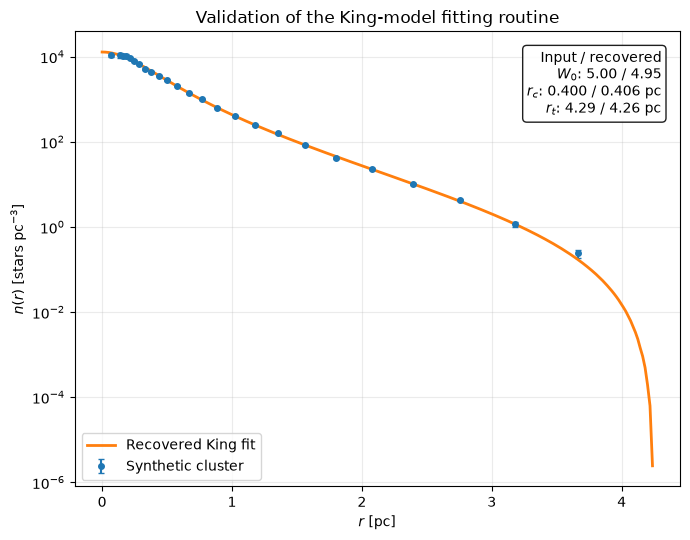

In [41]:
from amuse.ic.kingmodel import new_king_model
from amuse.io import write_set_to_file

def king_scale_ratios(w0):
    # Convert the dimensionless King model to the physical rc chosen for the validation test, can this be done differently with AMUSE? 
    king = MakeKingModel(number_of_particles=1, W0=float(w0))
    nprof, _ = king.poisson()

    rr = np.asarray(king.rr[:nprof + 1], dtype=float)
    mass = np.asarray(king.zm[:nprof + 1], dtype=float)
    mass /= mass[-1]

    dm = np.diff(mass)
    potential = -np.sum(
        dm * (mass[1:] + mass[:-1]) / (rr[1:] + rr[:-1])
    )

    return -0.5 / potential, rr[-1]

np.random.seed(42)

W0_input = 5.0
rc_input = 0.400 | units.parsec
N_input = 10000
M_input = 6000.0 | units.MSun

# Convert our rc into the corresponding Rvir for this W0.
rvir_over_rc, rt_over_rc = king_scale_ratios(W0_input)
rvir_input = rvir_over_rc * rc_input
rt_input = rt_over_rc * rc_input

converter_validation = nbody_system.nbody_to_si(M_input, rvir_input)

# Generate a realization of the theoretical King model
synthetic = new_king_model(
    N_input,
    W0=W0_input,
    convert_nbody=converter_validation,
    do_scale=False,
)
synthetic.move_to_center()

filename = "synthetic_king_W0_5.amuse"
write_set_to_file(
    synthetic,
    filename,
    "amuse",
    overwrite_file=True,
)

synthetic_test = read_set_from_file(filename, format="amuse")
synthetic_test.move_to_center()

(
    syn_r,
    syn_edges,
    syn_counts,
    syn_r_mid,
    syn_density,
    syn_density_error,
) = radial_number_density_profile(synthetic_test)

validation_best, _ = fit_king_model(
    syn_edges,
    syn_counts,
    len(synthetic_test),
    syn_r.max(),
    w0_min=2.0,
    w0_max=10.0,
)

W0_rec = validation_best["W0"]
rc_rec = validation_best["rc"]
rt_rec = validation_best["rt"]

rc_input_pc = rc_input.value_in(units.parsec)
rt_input_pc = rt_input.value_in(units.parsec)

print("Input -> recovered")
print(f"W0: {W0_input:.2f} -> {W0_rec:.2f}")
print(f"rc: {rc_input_pc:.4f} -> {rc_rec:.4f} pc")
print(f"rt: {rt_input_pc:.4f} -> {rt_rec:.4f} pc")
print(f"Delta W0 = {(W0_rec / W0_input - 1) * 100:+.2f}%")
print(f"Delta rc = {(rc_rec / rc_input_pc - 1) * 100:+.2f}%")
print(f"Delta rt = {(rt_rec / rt_input_pc - 1) * 100:+.2f}%")

x_val, rho_val, integ_val = king_profile(W0_rec)
n0_val = len(synthetic_test) / (
    4.0 * np.pi * rc_rec**3 * integ_val[-1]
)
r_val_model = x_val * rc_rec
n_val_model = n0_val * rho_val

mask_syn = syn_counts > 0
mask_val = n_val_model > 0

plt.figure(figsize=(7, 5.5))
plt.errorbar(
    syn_r_mid[mask_syn],
    syn_density[mask_syn],
    yerr=syn_density_error[mask_syn],
    fmt="o",
    markersize=4,
    capsize=2,
    label="Synthetic cluster",
)
plt.plot(
    r_val_model[mask_val],
    n_val_model[mask_val],
    linewidth=2,
    label="Recovered King fit",
)

validation_text = (
    "Input / recovered\n"
    fr"$W_0$: {W0_input:.2f} / {W0_rec:.2f}" "\n"
    fr"$r_c$: {rc_input_pc:.3f} / {rc_rec:.3f} pc" "\n"
    fr"$r_t$: {rt_input_pc:.2f} / {rt_rec:.2f} pc"
)
plt.text(
    0.97, 0.96, validation_text,
    transform=plt.gca().transAxes,
    ha="right", va="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.88),
)

plt.xlabel(r"$r$ [pc]")
plt.ylabel(r"$n(r)$ [stars pc$^{-3}$]")
plt.yscale("log")
plt.title("Validation of the King-model fitting routine")
plt.grid(alpha=0.25)
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()
